In [1]:
import matplotlib.pyplot as plt

### **Q1. 영상처리 기초 분석 (NumPy & OpenCV, 15분)**

다음 조건을 만족하는 함수를 작성하시오.

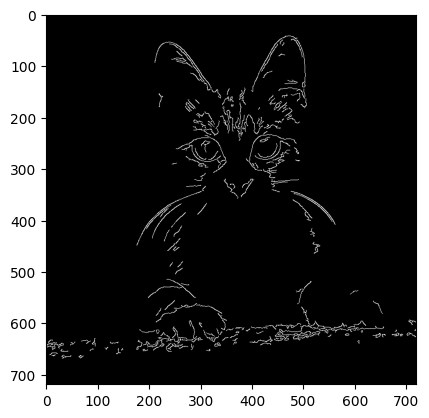

흰색 edge 픽셀 개수: 9208


In [9]:
import cv2
import numpy as np

def preprocess_image(img_path):
    """
    1. 이미지를 흑백(grayscale)으로 변환
    2. GaussianBlur (5x5 커널) 적용
    3. Canny Edge Detection 수행 (threshold1=100, threshold2=200)
    4. edge 이미지에서 흰색 픽셀 개수를 반환
    """
    img = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.GaussianBlur(img_gray, (5,5), 0)
    edge = cv2.Canny(img_blur, 100, 200)
    
    plt.imshow(edge, cmap='gray')
    plt.show()

    return np.count_nonzero(edge)
    

# 테스트
count = preprocess_image("test_image.jpg")
print("흰색 edge 픽셀 개수:", count)

### **Q2. 객체 인식 (YOLO 기반 탐지, 30분)**

사전학습된 YOLOv8 모델을 사용하여 `soldier.jpg` 이미지에서 사람(person)과 군사 장비(car, truck, helicopter 등) 객체를 탐지하시오.

조건:

1. Ultralytics YOLO 불러오기 (`yolov8n.pt`)
2. 사람과 군사 장비만 필터링하여 bounding box 출력
3. 탐지된 객체의 클래스 이름과 개수를 반환


image 1/1 /workspaces/study-and-commit/test_final/soldier.jpg: 448x640 4 persons, 1 airplane, 161.2ms
Speed: 3.1ms preprocess, 161.2ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)


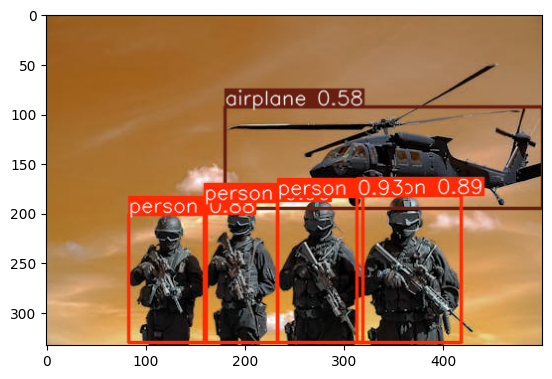

{'person': 4, 'airplane': 1}


In [21]:
from ultralytics import YOLO

def detect_objects(img_path):
    """
    YOLOv8을 이용해 객체 탐지 수행
    - 클래스 'person', 'car', 'truck', 'airplane', 'helicopter'만 반환
    - (class_name, count) 딕셔너리 형태로 반환
    """
    model = YOLO('yolov8n.pt')
    results = model(img_path, iou=0.5)

    plotted_img = results[0].plot()

    plt.imshow(plotted_img)
    plt.show()

    boxes = results[0].boxes

    dict_obj = dict()
    for box in boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]

        if class_name not in dict_obj:
            dict_obj[model.names[class_id]] = 1
        else:
            dict_obj[model.names[class_id]] += 1


    return dict_obj


result = detect_objects("soldier.jpg")
print(result)  # 예: {'person': 3, 'truck': 1}

### **Q3. 딥러닝 모델 구현 (PyTorch, 20분)**

MNIST 데이터셋을 이용하여 **2층 CNN**을 구현하고, test accuracy를 출력하시오.

조건:

1. `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, `nn.Linear` 사용
2. Optimizer는 Adam, Loss는 CrossEntropyLoss
3. Epoch = 1만 실행

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # 첫 번째 Conv2D + ReLU + MaxPool
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 1 입력 채널, 32 출력 채널
        self.pool = nn.MaxPool2d(2, 2)  # 2x2 MaxPooling
        
        # 두 번째 Conv2D + ReLU + MaxPool
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 입력 채널, 64 출력 채널
        
        # 전결합층 (Fully Connected Layer)
        self.fc1 = nn.Linear(7*7*64, 128)  # 7x7x64 크기의 feature map을 128로 연결
        self.fc2 = nn.Linear(128, 10)  # 128 -> 10 (MNIST의 10개 클래스)

    def forward(self, x):
        # 첫 번째 Convolutional Layer + Pooling
        x = self.pool(nn.ReLU()(self.conv1(x)))
        
        # 두 번째 Convolutional Layer + Pooling
        x = self.pool(nn.ReLU()(self.conv2(x)))
        
        # Feature map을 flatten하여 전결합층으로 입력
        x = x.view(-1, 7*7*64)
        
        # 전결합층
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)  # 최종 출력 (10 클래스)
        return x

def train_mnist():
    # 데이터 변환(Transform) 정의
    transform = transforms.Compose([
        transforms.ToTensor(), # 이미지를 텐서로 변환
        transforms.Normalize((0.5,), (0.5,)) # 이미지 정규화 (선택적)
    ])

    # MNIST 데이터셋 로드
    # root: 데이터가 저장될 경로
    # train: 훈련 데이터셋 여부
    # download: 데이터가 없으면 다운로드할지 여부
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # 데이터 로더(DataLoader) 생성
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

    model = SimpleCNN()
    criterion = nn.CrossEntropyLoss()  # Loss function for classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)  # Optimizer (Adam)

    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()  # Zero gradients
        output = model(data)  # Forward pass
        loss = criterion(output, target)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update parameters

        if batch_idx % 100 == 0:  # Print loss every 100 batches
            print(f'Train Batch {batch_idx}: Loss = {loss.item():.4f}')

        # Test the model after training
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():  # No need to track gradients for evaluation
        for data, target in test_loader:
            output = model(data)
            _, predicted = torch.max(output, 1)  # Get the predicted class
            total += target.size(0)
            correct += (predicted == target).sum().item()

    test_accuracy = 100.0 * correct / total  # Accuracy calculation
    print(f'Test Accuracy: {test_accuracy:.2f}%')


train_mnist()

Train Batch 0: Loss = 2.3136
Train Batch 100: Loss = 0.2586
Train Batch 200: Loss = 0.1728
Train Batch 300: Loss = 0.2151
Train Batch 400: Loss = 0.0256
Train Batch 500: Loss = 0.1185
Train Batch 600: Loss = 0.0201
Train Batch 700: Loss = 0.1772
Train Batch 800: Loss = 0.0902
Train Batch 900: Loss = 0.0592
Test Accuracy: 98.37%


### **Q4. 텍스트 기반 분류 (NLP, 20분)**

군사 관련 뉴스 데이터 일부가 주어졌다고 가정한다. 각 문장을 **긍정(1)/부정(0)** 으로 분류하는 모델을 구현하시오.

조건:

1. `scikit-learn`의 `TfidfVectorizer` 사용
2. 분류기는 `LogisticRegression`
3. accuracy 출력

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def text_classification(train_texts, train_labels, test_texts, test_labels):
    """
    1. TF-IDF 벡터화
    2. Logistic Regression 학습
    3. Accuracy 출력
    """
    # 1. Initialize TfidfVectorizer and convert text data into TF-IDF features
    # The vectorizer is fitted on the training data and then used to transform both train and test data.
    vectorizer = TfidfVectorizer()
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)

    # 2. Initialize and train the Logistic Regression model
    model = LogisticRegression()
    model.fit(X_train, train_labels)

    # 3. Predict on the test set and calculate the accuracy
    predictions = model.predict(X_test)
    accuracy = accuracy_score(test_labels, predictions)
    
    # Print the result
    print(f"Accuracy: {accuracy}")

# 예시 데이터
train_texts = ["군 장비가 강력하다", "군사 훈련 실패", "작전 성공", "전투 손실", "성공적 임무 수행", "병력 손실", "전투력 증가", "임무 실패"]
train_labels = [1, 0, 1, 0, 1, 0, 1, 0]
test_texts = ["군사 장비 성공", "작전 실패", "아군 전멸", "적 섬멸"]
test_labels = [1, 0, 0, 1]

text_classification(train_texts, train_labels, test_texts, test_labels)

Accuracy: 0.75
